# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [46]:
from __future__ import annotations

import torch
from sympy import denom
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [47]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        with torch.no_grad():
            self.weight.zero_()
            bound = (6.0 / (in_features + out_features))**0.5
            self.weight.uniform_(-bound, bound)
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.register_parameter('bias', None)
        return


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        xw = torch.einsum("...i, oi -> ...o", x, self.weight)

        #xw= torch.matmul(x, self.weight.t())
        if self.bias is not None:
            return xw + self.bias
        return xw

in_features, out_features = 4, 2
batch_size, seq_len = 3, 5

my_linear = Linear(in_features, out_features, bias=True)
x = torch.randn(batch_size, seq_len, in_features)
output = my_linear(x)
print(output)

ref_linear = nn.Linear(in_features, out_features)
with torch.no_grad():
    ref_linear.weight.copy_(my_linear.weight)
    ref_linear.bias.copy_(my_linear.bias)
ref_output = ref_linear(x)

print(torch.allclose(output, ref_output))




tensor([[[-0.4704,  0.8065],
         [ 0.6496,  0.4795],
         [-3.3320,  2.8982],
         [ 1.3750,  2.5674],
         [-1.5180,  1.3942]],

        [[-1.7873, -0.3572],
         [ 0.5815,  0.8650],
         [-1.4039,  0.5799],
         [-0.4998, -0.8151],
         [ 0.0908,  0.4637]],

        [[-1.4653, -2.2256],
         [ 1.7199,  0.0050],
         [ 1.2563,  1.3475],
         [ 1.2041, -1.4237],
         [ 0.9060,  1.6655]]], grad_fn=<AddBackward0>)
True


In [48]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))
        with torch.no_grad():
            self.weight.normal_(0, 0.02)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [49]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.prob = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if self.training:
            scale = 1/(1-self.prob)
            probVec = torch.Tensor([self.prob]).expand(x.shape)
            decision = torch.bernoulli(probVec)
            return x*scale*decision
        else: return x

x = torch.Tensor([[2.0,4.0,5.0,6.0,7.0,89.0,6.0],[3.0,7.0,8.0,3.0,3.0,7.0,3.0]])
out = Dropout(0.2)(x)
print(out)


tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 3.7500, 0.0000, 0.0000, 0.0000]])


## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [50]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.elementwise_affine = elementwise_affine


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        std = (x.var(dim=-1, keepdim=True, unbiased=False) + self.eps)**0.5
        norm = (x - mean) / std
        if self.elementwise_affine:
            x = self.weight * norm + self.bias
        return x
dim = 4
ln = LayerNorm(normalized_shape=dim, eps=1e-5)
x = torch.randn(2, 3, dim) * 10 + 5

out = ln(x)
print(f"Input Shape:  {x.shape}")
print(f"Output Shape: {out.shape}")


Input Shape:  torch.Size([2, 3, 4])
Output Shape: torch.Size([2, 3, 4])


In [51]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        meansq = torch.mean(x**2, dim=-1, keepdim=True)
        denom = (meansq + self.eps)**0.5
        return (x / denom) * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [52]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        layerStructure = nn.ModuleList()
        if use_layernorm:
            for _ in range(depth):
                layerStructure.append(LayerNorm(hidden_dim))
                layerStructure.append(Linear(hidden_dim, hidden_dim))
                layerStructure.append(nn.GELU())

        else:
            for _ in range(depth):
                layerStructure.append(Linear(hidden_dim, hidden_dim))
                layerStructure.append(nn.GELU())

        self.model = nn.Sequential(Linear(in_dim, hidden_dim), nn.GELU(), *layerStructure, Linear(hidden_dim, out_dim))
        if use_layernorm:
            self.model.insert(-1, LayerNorm(hidden_dim))
            self.model.insert(0, LayerNorm(in_dim))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

test_mlp = MLP(in_dim=4, hidden_dim=8, out_dim=2, depth=1, use_layernorm=True)

print(test_mlp)

dummy_input = torch.randn(1, 4)
output = test_mlp(dummy_input)
print(f"\nOutput shape: {output.shape}")


MLP(
  (model): Sequential(
    (0): LayerNorm()
    (1): Linear()
    (2): GELU(approximate='none')
    (3): LayerNorm()
    (4): Linear()
    (5): GELU(approximate='none')
    (6): LayerNorm()
    (7): Linear()
  )
)

Output shape: torch.Size([1, 2])


In [53]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: create two Linear layers and choose an activation (GELU)
        self.net = nn.Sequential(Linear(d_model, d_ff), nn.GELU(), Linear(d_ff, d_model))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

d_model = 512
ffn = FeedForward(d_model=d_model)
test_input = torch.randn(1, 10, d_model)
output = ffn(test_input)

print(f"Input shape:  {test_input.shape}")  # (1, 10, 512)
print(f"Output shape: {output.shape}")      # (1, 10, 512)

Input shape:  torch.Size([1, 10, 512])
Output shape: torch.Size([1, 10, 512])


In [54]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # TODO: return x + fn(x, ...)
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [55]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [56]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# TODO: define the dataloaders
def make_dataloader(
    dataset: Dataset,
    batch_size: int,
    shuffle: bool = True,
    drop_last: bool = False,
    collate_fn=None,
    num_workers: int = 0,
) -> DataLoader:
    """
    Create a DataLoader with optional collate_fn.
    """
    dataloader = DataLoader(dataset, batch_size=batch_size, drop_last=drop_last,shuffle=shuffle, num_workers=num_workers, collate_fn=collate_fn)
    return dataloader

print(len(train_ds))
print(len(test_ds))

batch_size = 64

train_loader = make_dataloader(train_ds, batch_size=batch_size)
test_loader = make_dataloader(test_ds, batch_size=batch_size)

60000
10000


In [57]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    logsoft = nn.LogSoftmax(dim=-1)
    loss = logsoft(logits)
    mask = torch.nn.functional.one_hot(targets, num_classes=logits.shape[1])
    selected = (loss * mask).sum(dim=1)
    return -torch.mean(selected)


y = torch.Tensor([[3.0,4.0],[1.0,6.0]])
logsoft = nn.LogSoftmax(dim=-1)
print(logsoft(y))


tensor([[-1.3133, -0.3133],
        [-5.0067, -0.0067]])


In [58]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.linear = nn.Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.linear(x)

In [59]:
def accuracy(loader, model):
    # TODO: You can use this function to evaluate your model accuracy.
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.flatten(1)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total

In [60]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    # TODO: implement
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    torch.manual_seed(seed)
    train_losses = []
    for epoch in range(epochs):
        model.train()
        for x, y in train_data_loader:
            x = x.flatten(1)
            output = model(x)
            loss = cross_entropy_from_logits(output, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        test_acc = accuracy(test_data_loader, model)
        #prediction = model(x_test)
        #accuracy = accuracy(y_test, prediction)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Test Acc: {test_acc:.2f}%")

    return train_losses






Epoch 1/5 | Loss: 0.2514 | Test Acc: 95.58%
Epoch 2/5 | Loss: 0.2492 | Test Acc: 97.44%
Epoch 3/5 | Loss: 0.0873 | Test Acc: 96.68%
Epoch 4/5 | Loss: 0.0947 | Test Acc: 97.66%
Epoch 5/5 | Loss: 0.0710 | Test Acc: 97.78%


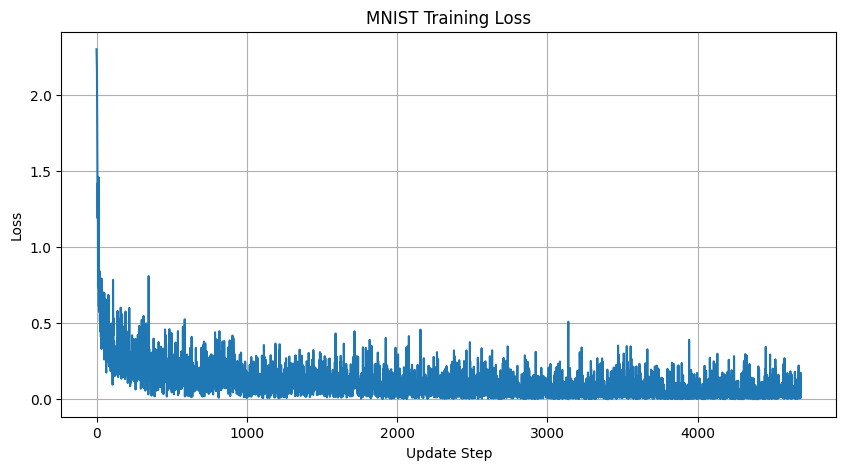


Final Test Accuracy: 97.78%


In [61]:
LR = 1e-3
EPOCHS = 5
# 3. Create instances
model = nn.Sequential(
    MLP(
        784,
        512,
        256,
        4
    ), ClassificationHead(256, 10)
)

train_losses = train_classifier(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=test_loader,
    lr=LR,
    epochs=EPOCHS
)

#import matplotlib.pyplot as plt

#plt.figure(figsize=(10, 5))
#plt.plot(train_losses)
#plt.grid(True)
#plt.show()
final_acc = accuracy(test_loader, model)
print(f"\nFinal Test Accuracy: {final_acc:.2f}%")